In [4]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
# Style settings
sns.set_theme(style='whitegrid')
%matplotlib inline
# Color palette
TEAL   = '#0D7680'
ORANGE = '#B5540A'
BLUE   = '#1B5E83'
PURPLE = '#5B3A8F'
GREEN  = '#2E5E1E'
DARK   = '#1A1A2E'
print('All libraries imported successfully!')

All libraries imported successfully!


In [5]:
# Place students.csv in the same folder as this notebook
DATA_PATH = 'students.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape  : {df.shape}')   # (rows, columns)
print(f'Columns: {list(df.columns)}')

Shape  : (1050, 13)
Columns: ['student_id', 'gender', 'parental_education', 'family_income', 'internet_access', 'extra_classes', 'health_status', 'prev_score', 'study_hours_per_day', 'attendance_pct', 'sleep_hours', 'final_score', 'pass_fail']


In [6]:
# See the first 5 rows
df.head()
# Also useful:
#df.tail() 
#→ last 5 rows
# df.sample(5)  → random 5 rows


,student_id,gender,parental_education,family_income,internet_access,extra_classes,health_status,prev_score,study_hours_per_day,attendance_pct,sleep_hours,final_score,pass_fail
0,1,Male,Postgraduate,Medium,Yes,Yes,Good,44.0,4.6,76.4,9.4,43.60,Fail
1,2,Female,Secondary,Medium,Yes,Yes,Good,27.3,6.2,71.0,7.0,35.05,Fail
2,3,Female,Postgraduate,Low,No,No,Good,74.9,5.5,85.2,7.5,53.94,Pass
3,4,Female,Graduate,Medium,No,Yes,Excellent,49.6,2.8,70.5,8.6,46.98,Fail
4,5,Male,Postgraduate,Medium,Yes,No,Excellent,31.7,3.2,70.1,6.8,37.30,Fail


=== Data Info ===
student_id                  int64
gender                     object
parental_education         object
family_income              object
internet_access            object
extra_classes              object
health_status              object
prev_score                float64
study_hours_per_day       float64
attendance_pct            float64
sleep_hours               float64
final_score               float64
pass_fail                  object
parental_education_enc      int64
health_status_enc           int64
family_income_enc           int64
internet_enc                int64
extra_class_enc             int64
gender_enc                  int64
study_efficiency          float64
target                      int64
dtype: object

=== Missing Values ===
student_id                0
gender                    0
parental_education        0
family_income             0
internet_access           0
extra_classes             0
health_status             0
prev_score                0
study_

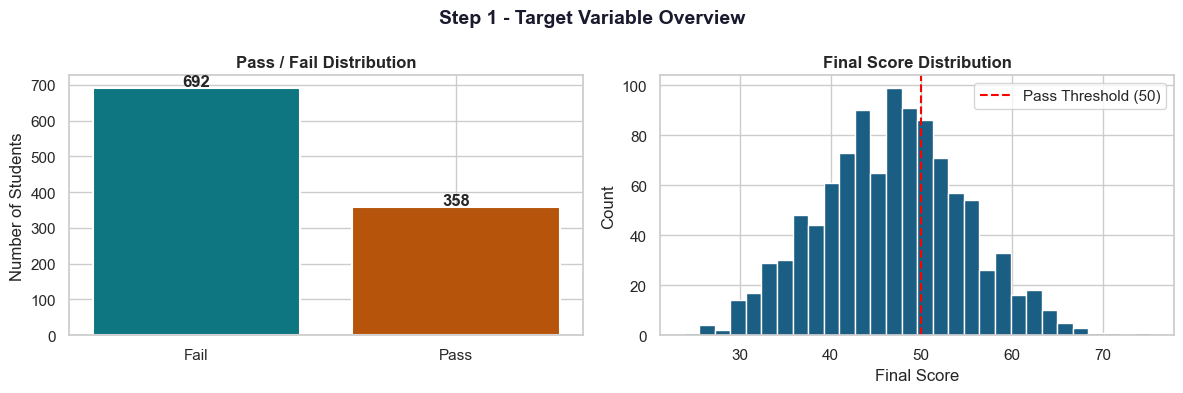

In [21]:
# Data types and non-null counts
print('=== Data Info ===')
print(df.dtypes)
print()
# Count missing values per column
print('=== Missing Values ===')
print(df.isnull().sum())
print()
# Target variable distribution
print('=== Target: pass_fail ===')
print(df['pass_fail'].value_counts())
print()
print('Percentage:')
print(df['pass_fail'].value_counts(normalize=True).mul(100).round(1))
# VISUALISE: target bar chart + final_score histogram
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Step 1 - Target Variable Overview',
fontsize=14, fontweight='bold', color=DARK)
counts = df['pass_fail'].value_counts()
axes[0].bar(counts.index, counts.values,
color=[TEAL, ORANGE], edgecolor='white', linewidth=1.5)
axes[0].set_title('Pass / Fail Distribution', fontweight='bold')
axes[0].set_ylabel('Number of Students')
for i, v in enumerate(counts.values):
 axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].hist(df['final_score'].dropna(), bins=30,
color=BLUE, edgecolor='white')
axes[1].axvline(50, color='red', linestyle='--', label='Pass Threshold (50)')
axes[1].set_title('Final Score Distribution', fontweight='bold')
axes[1].set_xlabel('Final Score')
axes[1].set_ylabel('Count')
axes[1].legend()
plt.tight_layout()
plt.savefig("charts/tight_layout.png")
plt.show()


In [9]:
# Numerical columns that may have NaN
num_cols = ['prev_score', 'study_hours_per_day', 'attendance_pct', 'sleep_hours']
for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"Filled '{col}' NaN → median = {median_val:.2f}")
# Confirm: zero NaN remaining
print()
print(f'Missing after clean: {df[num_cols].isnull().sum().sum()}  (should be 0)')

Filled 'prev_score' NaN → median = 61.50
Filled 'study_hours_per_day' NaN → median = 4.50
Filled 'attendance_pct' NaN → median = 75.00
Filled 'sleep_hours' NaN → median = 7.00

Missing after clean: 0  (should be 0)


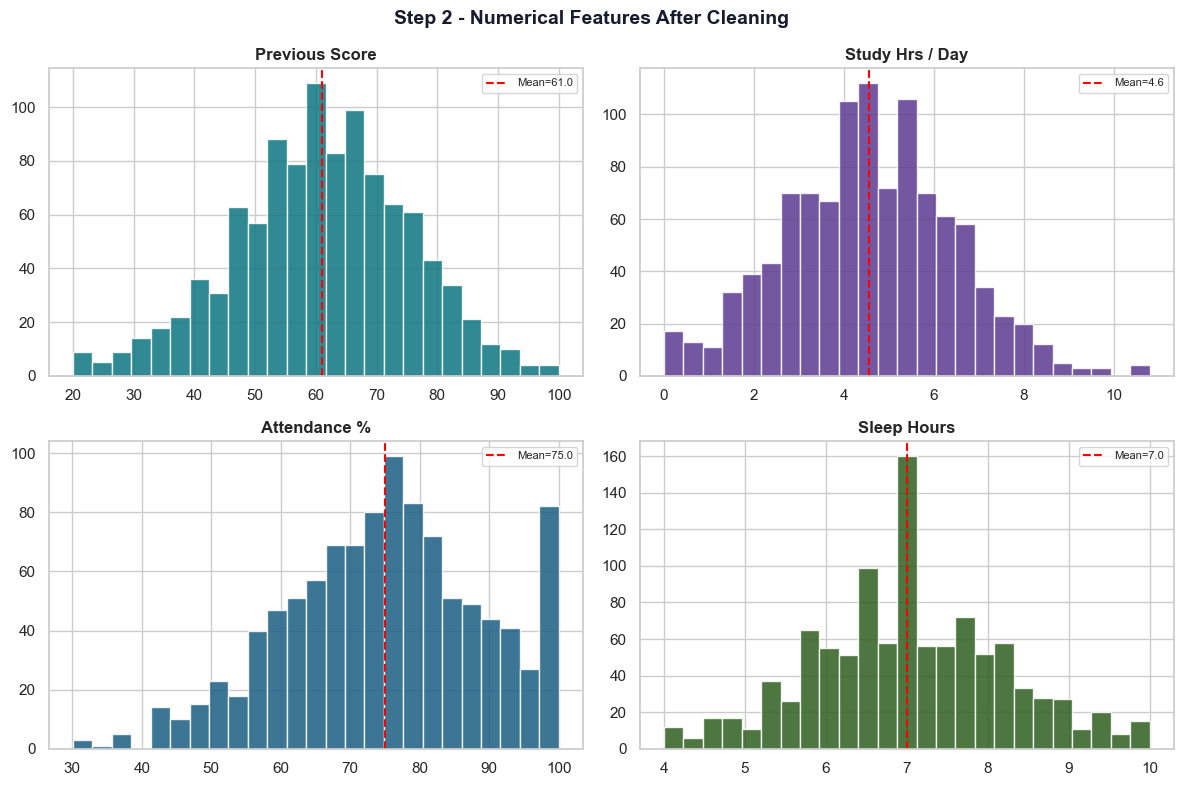

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Step 2 - Numerical Features After Cleaning',
             fontsize=14, fontweight='bold', color=DARK)
feature_info = [
    ('prev_score',           TEAL,   'Previous Score'),
    ('study_hours_per_day',  PURPLE, 'Study Hrs / Day'),
    ('attendance_pct',       BLUE,   'Attendance %'),
    ('sleep_hours',          GREEN,  'Sleep Hours'),
]
for ax, (feat, col, label) in zip(axes.flat, feature_info):
    ax.hist(df[feat], bins=25, color=col, edgecolor='white', alpha=0.85)
    ax.axvline(df[feat].mean(), color='red', linestyle='--',
               label=f'Mean={df[feat].mean():.1f}')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("charts/tight_layout.png")
plt.show()

In [11]:
# Ordinal mappings — order matters (Poor < Average < Good < Excellent)
PARENT_EDU_MAP = {
    'No Education': 0, 'Primary': 1, 'Secondary': 2,
    'Graduate': 3, 'Postgraduate': 4
}
HEALTH_MAP  = {'Poor': 0, 'Average': 1, 'Good': 2, 'Excellent': 3}
INCOME_MAP  = {'Low': 0, 'Medium': 1, 'High': 2}
TARGET_MAP  = {'Fail': 0, 'Pass': 1}   # target: 0=Fail, 1=Pass
# Validate — catch unknown values BEFORE mapping (fail fast)
for col, mapping in [
    ('parental_education', PARENT_EDU_MAP),
    ('health_status',      HEALTH_MAP),
    ('family_income',      INCOME_MAP),
]:
    unknown = set(df[col].dropna().unique()) - set(mapping.keys())
    if unknown:
        raise ValueError(f'Unknown values in {col}: {unknown}')
    else:
        print(f'{col}  OK — all values recognised')

parental_education  OK — all values recognised
health_status  OK — all values recognised
family_income  OK — all values recognised


Features shape : (1050, 11)
Target classes : {0: 692, 1: 358}


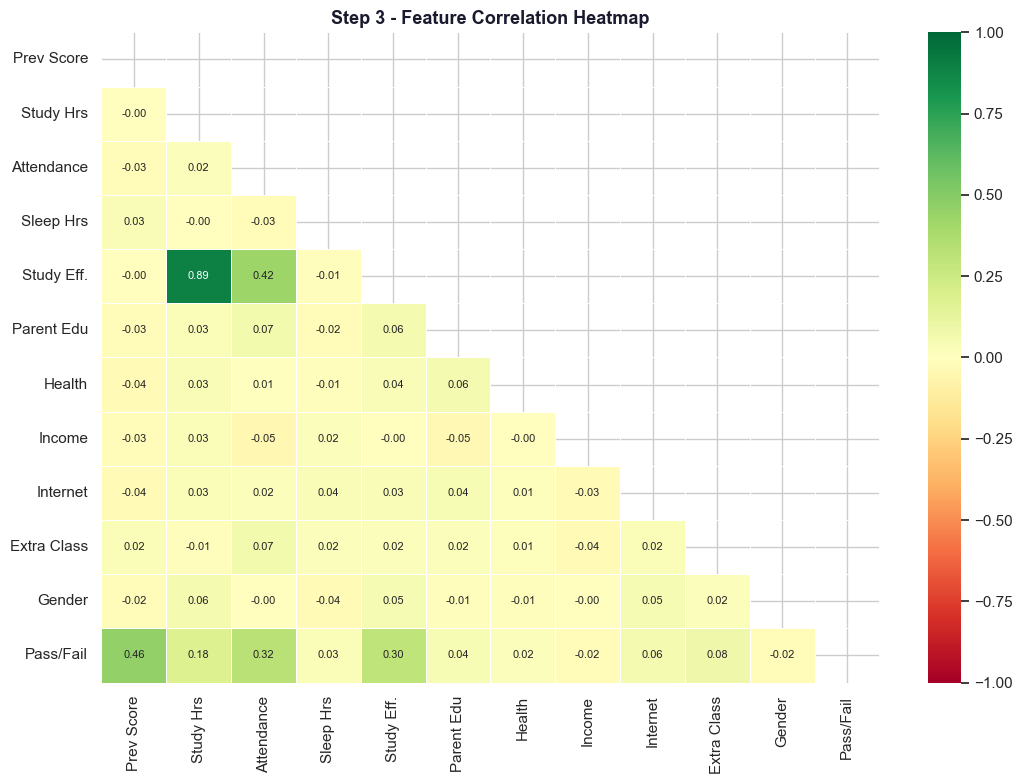

In [23]:
# Apply all encodings in one df.assign() call
df = df.assign(
    parental_education_enc = df['parental_education'].map(PARENT_EDU_MAP),
    health_status_enc      = df['health_status'].map(HEALTH_MAP),
    family_income_enc      = df['family_income'].map(INCOME_MAP),
    internet_enc           = (df['internet_access'] == 'Yes').astype(int),
    extra_class_enc        = (df['extra_classes'] == 'Yes').astype(int),
    gender_enc             = (df['gender'] == 'Male').astype(int),

    # NEW FEATURE: study_efficiency = hours × attendance%
    study_efficiency = (
        df['study_hours_per_day'] * df['attendance_pct'] / 100
    ).round(2),

    target = df['pass_fail'].map(TARGET_MAP),
)

# Define feature list
FEATURES = [
    'prev_score',
    'study_hours_per_day',
    'attendance_pct',
    'sleep_hours',
    'study_efficiency',
    'parental_education_enc',
    'health_status_enc',
    'family_income_enc',
    'internet_enc',
    'extra_class_enc',
    'gender_enc'
]

X = df[FEATURES].copy()
y = df['target']

# Verify no NaN in X
assert X.isnull().sum().sum() == 0, 'NaN found in features!'

print(f'Features shape : {X.shape}')
print(f'Target classes : {y.value_counts().to_dict()}')

# Correlation heatmap
NICE = [
    'Prev Score',
    'Study Hrs',
    'Attendance',
    'Sleep Hrs',
    'Study Eff.',
    'Parent Edu',
    'Health',
    'Income',
    'Internet',
    'Extra Class',
    'Gender',
    'Pass/Fail'
]

corr_df = df[FEATURES + ['target']].copy()
corr_df.columns = NICE

fig, ax = plt.subplots(figsize=(11, 8))

import numpy as np

mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    mask=mask,
    linewidths=0.5,
    ax=ax,
    vmin=-1,
    vmax=1,
    annot_kws={'size': 8}
)

ax.set_title(
    'Step 3 - Feature Correlation Heatmap',
    fontsize=13,
    fontweight='bold',
    color=DARK
)

plt.tight_layout()
plt.savefig("charts/target_layoput.png")
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,      # 20% for testing
    random_state=42,     # fixed seed → same split every run
    stratify=y           # keep Pass/Fail ratio same in both sets
)
print(f'Train size : {X_train.shape[0]} students')
print(f'Test  size : {X_test.shape[0]}  students')
print()
print('Class balance — Train:')
print(f'  Fail = {(y_train==0).sum()}  |  Pass = {(y_train==1).sum()}')
print('Class balance — Test:')
print(f'  Fail = {(y_test==0).sum()}   |  Pass = {(y_test==1).sum()}')

Train size : 840 students
Test  size : 210  students

Class balance — Train:
  Fail = 554  |  Pass = 286
Class balance — Test:
  Fail = 138   |  Pass = 72


In [14]:
#  Model 1: Logistic Regression (wrapped in Pipeline) 
# Pipeline applies StandardScaler BEFORE LR — inside every CV fold
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(max_iter=500, random_state=42))
])
#  Model 2: Decision Tree 
dt = DecisionTreeClassifier(
    max_depth=6,        # limits tree depth to prevent overfitting
    random_state=42
)
#  Model 3: Random Forest 
rf = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees in the forest
    max_depth=10,
    random_state=42,
    n_jobs=-1           # use all CPU cores
)
#  Train (fit) all 3 models on training data 
lr_pipeline.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
print('All 3 models trained successfully!')
print('LR uses Pipeline with internal StandardScaler (no data leakage)')

All 3 models trained successfully!
LR uses Pipeline with internal StandardScaler (no data leakage)


In [15]:
# StratifiedKFold: 5-fold CV, shuffled, reproducible
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = {}

for name, model in [
    ('Logistic Regression', lr_pipeline),
    ('Decision Tree', dt),
    ('Random Forest', rf),
]:

    # Test set prediction
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    # Cross-validation on training data
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring='accuracy'
    )

    # Store results
    results[name] = {
        'accuracy': acc,
        'cv_accuracy': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }

    # Print metrics
    print(f'=== {name} ===')

    print(f'Test Accuracy : {acc*100:.2f}%')

    print(
        f'CV Accuracy   : '
        f'{cv_scores.mean()*100:.2f}% +/- '
        f'{cv_scores.std()*100:.2f}%'
    )

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=['Fail', 'Pass'],
            digits=3
        )
    )

    print()

=== Logistic Regression ===
Test Accuracy : 78.57%
CV Accuracy   : 81.07% +/- 2.70%
              precision    recall  f1-score   support

        Fail      0.816     0.870     0.842       138
        Pass      0.714     0.625     0.667        72

    accuracy                          0.786       210
   macro avg      0.765     0.747     0.754       210
weighted avg      0.781     0.786     0.782       210


=== Decision Tree ===
Test Accuracy : 74.29%
CV Accuracy   : 74.88% +/- 5.63%
              precision    recall  f1-score   support

        Fail      0.788     0.833     0.810       138
        Pass      0.641     0.569     0.603        72

    accuracy                          0.743       210
   macro avg      0.714     0.701     0.706       210
weighted avg      0.737     0.743     0.739       210


=== Random Forest ===
Test Accuracy : 80.00%
CV Accuracy   : 78.57% +/- 1.06%
              precision    recall  f1-score   support

        Fail      0.804     0.920     0.858      

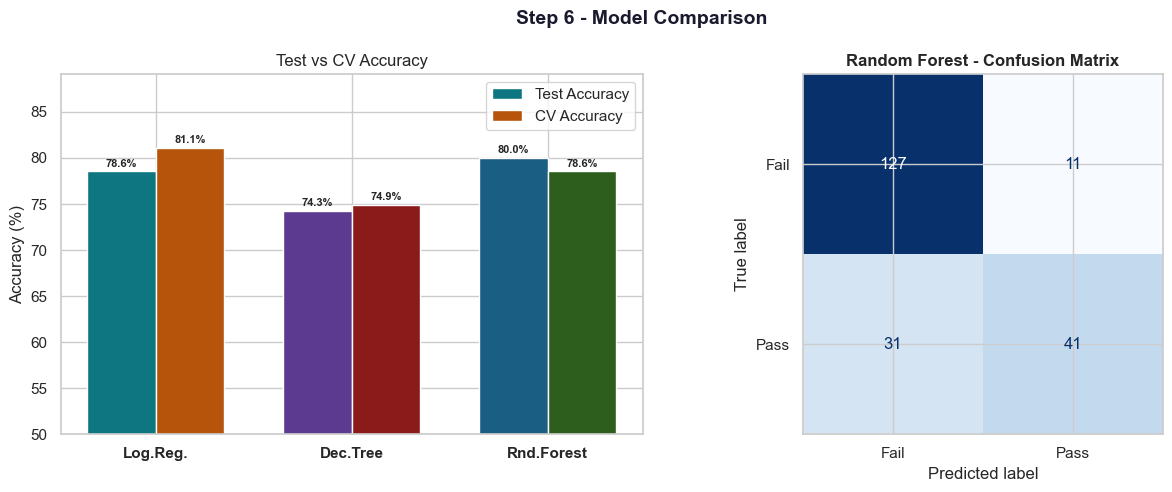

In [24]:
import numpy as np
accs   = [results[n]['accuracy']    * 100 for n in results]
cv_acc = [results[n]['cv_accuracy'] * 100 for n in results]
names  = list(results.keys())
y_max  = max(accs + cv_acc) + 8   # dynamic ceiling (not hardcoded!)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Step 6 - Model Comparison',
             fontsize=14, fontweight='bold', color=DARK)
#  Grouped bar chart 
x, w = np.arange(len(names)), 0.35
axes[0].bar(x - w/2, accs,   w, label='Test Accuracy',
            color=[TEAL, PURPLE, BLUE], edgecolor='white')
axes[0].bar(x + w/2, cv_acc, w, label='CV Accuracy',
            color=[ORANGE, '#8B1A1A', GREEN], edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Log.Reg.', 'Dec.Tree', 'Rnd.Forest'],
                         fontweight='bold')
axes[0].set_ylim(50, y_max)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Test vs CV Accuracy')
axes[0].legend()
for i, (a, c) in enumerate(zip(accs, cv_acc)):
    axes[0].text(i - w/2, a + 0.5, f'{a:.1f}%',
                 ha='center', fontsize=8, fontweight='bold')
    axes[0].text(i + w/2, c + 0.5, f'{c:.1f}%',
                 ha='center', fontsize=8, fontweight='bold')
#  Confusion Matrix for best model (Random Forest) 
cm   = confusion_matrix(y_test, results['Random Forest']['y_pred'])
disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Random Forest - Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig("charts/target_layout.png")
plt.show()

Feature Importance Ranking (Random Forest):
---------------------------------------------
Previous Score        : 0.3190  +++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Attendance %          : 0.1864  +++++++++++++++++++++++++++++++++++++
Study Efficiency      : 0.1698  +++++++++++++++++++++++++++++++++
Study Hrs/Day         : 0.0991  +++++++++++++++++++
Sleep Hours           : 0.0828  ++++++++++++++++
Parental Education    : 0.0401  ++++++++
Health Status         : 0.0321  ++++++
Family Income         : 0.0251  +++++
Extra Classes         : 0.0173  +++
Internet Access       : 0.0148  ++
Gender                : 0.0133  ++


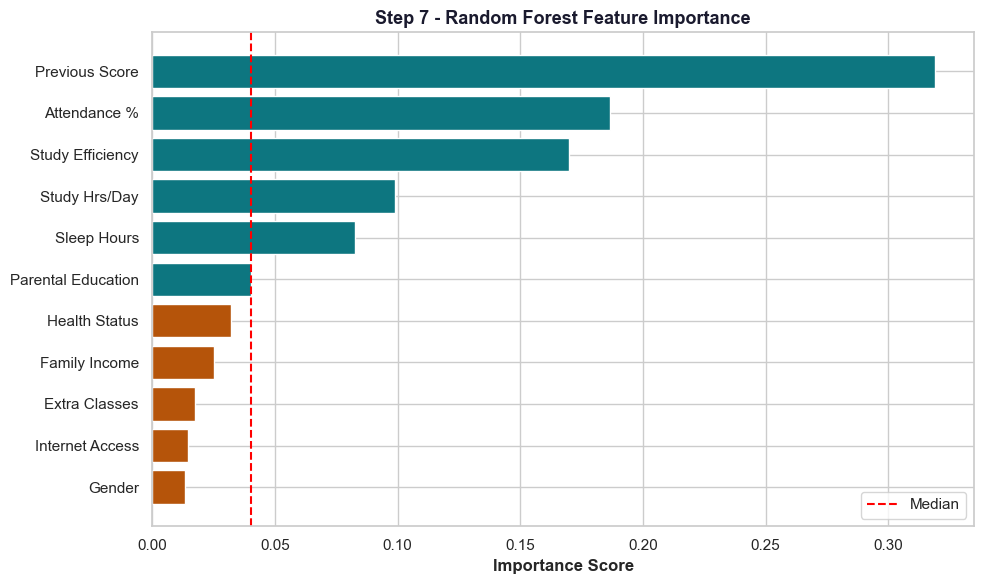

In [17]:
import numpy as np
FEAT_LABELS = [
    'Previous Score', 'Study Hrs/Day', 'Attendance %', 'Sleep Hours',
    'Study Efficiency', 'Parental Education', 'Health Status',
    'Family Income', 'Internet Access', 'Extra Classes', 'Gender'
]
importances = rf.feature_importances_
sorted_idx  = np.argsort(importances)   # sort from lowest to highest
# Print ranked list in console
print('Feature Importance Ranking (Random Forest):')
print('-' * 45)
for i in sorted_idx[::-1]:   # reverse = highest first
    bar = '+' * int(importances[i] * 200)
    print(f'{FEAT_LABELS[i]:<22}: {importances[i]:.4f}  {bar}')
# Plot horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = [TEAL if importances[i] >= np.median(importances)
              else ORANGE for i in sorted_idx]
ax.barh([FEAT_LABELS[i] for i in sorted_idx],
        importances[sorted_idx], color=bar_colors, edgecolor='white')
ax.axvline(np.median(importances), color='red', linestyle='--', label='Median')
ax.set_xlabel('Importance Score', fontweight='bold')
ax.set_title('Step 7 - Random Forest Feature Importance',
             fontsize=13, fontweight='bold', color=DARK)
ax.legend()
plt.tight_layout()
plt.show()

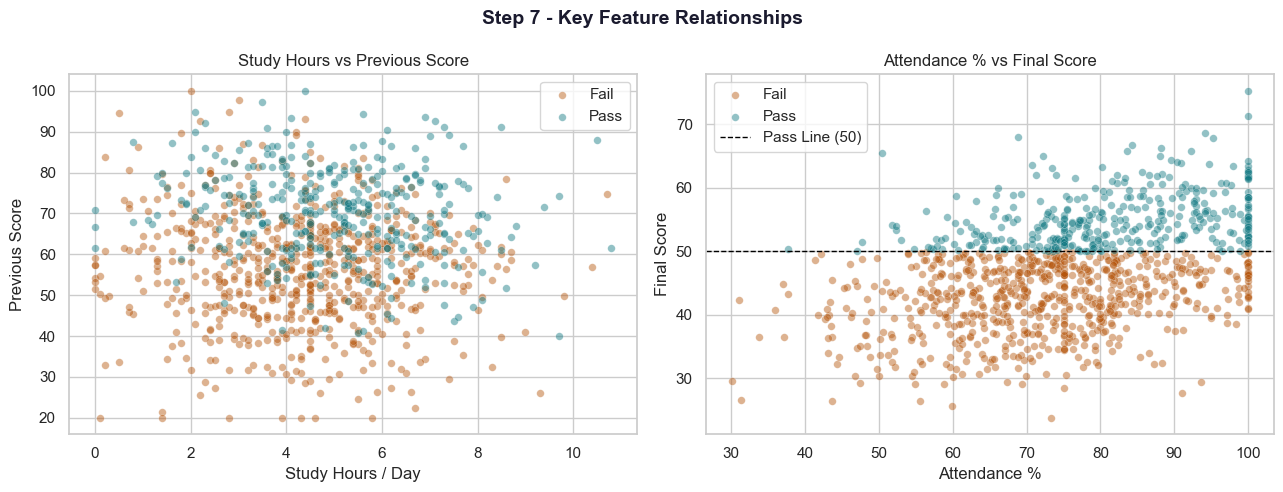

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Step 7 - Key Feature Relationships',
             fontsize=14, fontweight='bold', color=DARK)
color_map = {0: ORANGE, 1: TEAL}   # 0=Fail (orange), 1=Pass (teal)
for outcome, grp in df.groupby('target'):
    lbl = 'Pass' if outcome == 1 else 'Fail'
    # Chart 1: Study Hours vs Previous Score
    axes[0].scatter(
        grp['study_hours_per_day'], grp['prev_score'],
        c=color_map[outcome], label=lbl,
        alpha=0.45, edgecolors='white', linewidth=0.3, s=30
    )
    # Chart 2: Attendance % vs Final Score
    axes[1].scatter(
        grp['attendance_pct'], grp['final_score'],
        c=color_map[outcome], label=lbl,
        alpha=0.45, edgecolors='white', linewidth=0.3, s=30
    )
axes[0].set_xlabel('Study Hours / Day')
axes[0].set_ylabel('Previous Score')
axes[0].set_title('Study Hours vs Previous Score')
axes[0].legend()
axes[1].axhline(50, color='black', linestyle='--',
                linewidth=1, label='Pass Line (50)')
axes[1].set_xlabel('Attendance %')
axes[1].set_ylabel('Final Score')
axes[1].set_title('Attendance % vs Final Score')
axes[1].legend()
plt.tight_layout()
plt.savefig("charts/target_overview.png")
plt.show()

In [19]:
print('=' * 55)
print('  FINAL SUMMARY — MODEL COMPARISON')
print('=' * 55)
for name, res in results.items():
    print(f"  {name}")
    print(f"    Test Accuracy : {res['accuracy']*100:.2f}%")
    print(f"    CV  Accuracy  : {res['cv_accuracy']*100:.2f}%"
          f" +/- {res['cv_std']*100:.2f}%")
    print()
best = max(results, key=lambda k: results[k]['accuracy'])
print(f'  BEST MODEL : {best}')
print(f'  Test Acc   : {results[best]["accuracy"]*100:.2f}%')
print('=' * 55)

  FINAL SUMMARY — MODEL COMPARISON
  Logistic Regression
    Test Accuracy : 78.57%
    CV  Accuracy  : 81.07% +/- 2.70%

  Decision Tree
    Test Accuracy : 74.29%
    CV  Accuracy  : 74.88% +/- 5.63%

  Random Forest
    Test Accuracy : 80.00%
    CV  Accuracy  : 78.57% +/- 1.06%

  BEST MODEL : Random Forest
  Test Acc   : 80.00%
